In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

In [ ]:
# Load the 'unsupervised-learning-on-country-data' dataset
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path_country_data = "Country-data.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path_country_data,
)

print("First 5 records of country_df:")
display(df.head())

/tmp/ipykernel_9890/1215707381.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
First 5 records of country_df:


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Project Flow (Ideal Data Science Lifecycle)
### 1. Import Libraries
### 2. Load Dataset
### 3. Understand the Dataset
``` Shape
1. Columns
2. Data Types
3. Missing Values
4. Duplicate Values
5. Statistical Summary
```
### 4. Data Cleaning
``` This dataset is already very clean.

We'll only check

1. Missing Values
2. Duplicate Values
3. Wrong Data Types

No feature engineering is required because this is an unsupervised learning dataset.
```
### 5. Basic EDA
```
Numerical Distribution
Correlation Heatmap
Top 10 Highest Income Countries
GDP Distribution
Child Mortality Distribution
```
### 6. Feature Selection
```
Country name cannot be used.
Explain:
Country is just an identifier.
Machine learns only from numerical values.
```

### 7. Feature Scaling
```
K-Means is distance based.
So scaling is compulsory.
```
### 8. Finding Best K (Elbow Method)
### 9. Train K-Means
### 10. Test K-Means

In [ ]:
df.isnull().sum()


,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


<Axes: >

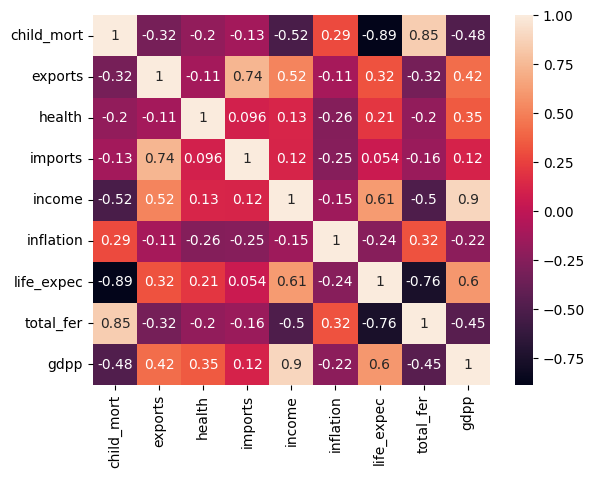

In [ ]:
import seaborn as sn
corr = df.corr(numeric_only=True)
sn.heatmap(corr , annot =True)

In [ ]:
df.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [ ]:
country = df['country'].unique()

In [ ]:
df.drop('country', axis = 1, inplace=True)

In [ ]:
# TOP 10 HIgest income
df.sort_values(by = 'income', ascending = False).head(10)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
123,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300
91,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
23,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300
82,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500
133,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
114,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800
157,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000
145,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
159,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400
73,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700


<Axes: ylabel='Frequency'>

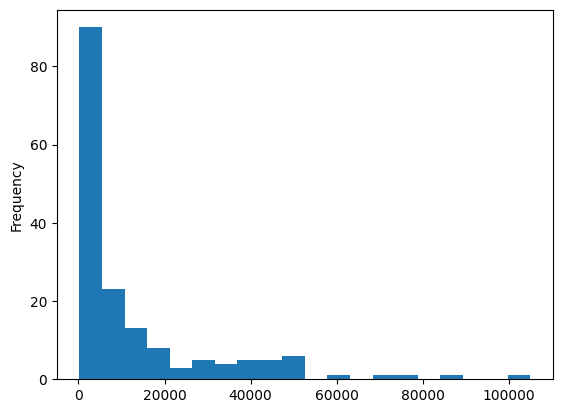

In [ ]:
from seaborn.categorical import KDE
# GDP Distribution

df['gdpp'].plot(kind = 'hist', bins = 20, )

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

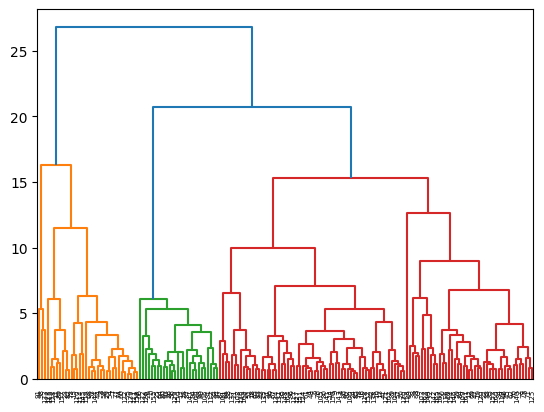

In [ ]:
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

link = linkage(df_scaled, method = 'ward')
dendrogram(link)
plt.show()